# 计算机视觉导论与 KNN 图像分类

本讲是 CS231n 的第一课。我们从最基本的问题出发：**给定一张图片，判断它属于哪个类别**。这看起来简单——人眼一秒就能完成——但对机器来说却极其困难。

我们会先建立直觉，然后用最朴素的分类器——**K-最近邻（KNN）**——来体会计算机视觉的核心挑战：**语义鸿沟**。


## 为什么计算机视觉难？

人眼看到一只猫，大脑瞬间完成判断。但计算机看到的是一个数字矩阵：

- 一张 32x32 的彩色图片 = 32 × 32 × 3 = **3072 个数字**
- 每个数字是 0~255 的像素值
- 猫的耳朵形状、毛发纹理、眼睛位置——这些语义概念在这个数字矩阵里**完全不存在**

这就是**语义鸿沟**：像素值和语义概念之间有一道巨大的鸿沟。计算机视觉的全部工作就是架起这座桥。


### 语义鸿沟示意

想象两张图片：一只白猫躺在白毯上，和一团白色的毛线。它们的像素值可能非常接近，但语义完全不同。反之，同一只猫在不同光照下的像素值可能天差地别，但语义相同。

**核心挑战**：如何让算法从原始像素中提取出对语义不变的特征？

这就是深度学习要解决的根本问题。但在直接用神经网络之前，让我们先理解最朴素的方法——KNN——为什么行不通，以及它教会我们什么。


## 1. 图像分类问题定义

**输入**：一张图片 x，表示为 H × W × 3 的像素张量

**输出**：一个类别标签 y ∈ {c1, c2, ..., cK}

**训练集**：{(x1, y1), (x2, y2), ..., (xN, yN)}

**目标**：学习一个函数 f: x → y，使得在未见过的图片上也能给出正确标签。

这就是**有监督学习**的基本设定。计算机视觉的特殊性在于输入维度极高——一张 32x32 的小图就有 3072 维，而 ImageNet 的标准输入 224x224 有 150528 维。


### 数据集：CIFAR-10

CIFAR-10 是计算机视觉最经典的入门数据集：

- **10 个类别**：飞机、汽车、鸟、猫、鹿、狗、蛙、马、船、卡车
- **图片大小**：32x32x3（很小，便于实验）
- **训练集**：50,000 张
- **测试集**：10,000 张

32x32 的分辨率意味着每张图片只有 1024 个像素。人眼勉强能认出物体，但细节已经大量丢失。这恰好适合我们理解分类的困难。


In [6]:
# 加载必要的库
import numpy as np
import matplotlib.pyplot as plt
import time
from collections import Counter

# 设置随机种子保证可复现
np.random.seed(42)

print("numpy version:", np.__version__)
print("matplotlib loaded successfully")


numpy version: 2.2.6
matplotlib loaded successfully


## 2. 最朴素的分类器：最近邻（Nearest Neighbor）

**直觉**：如果你遇到一张新图片，不知道它是什么，最自然的做法是——**在记忆中找一张最像的图片，借用它的标签**。

这就是最近邻分类器的核心思想：

1. 训练阶段：把所有训练图片和标签**存下来**（实际上没有训练）
2. 预测阶段：对于新图片 x，在训练集中找一张与 x 最相似的图片 xi，返回 yi

**相似度**怎么衡量？最直觉的方式是逐像素比较——计算两张图片像素值之差的绝对值总和。

$$d_1(x, x_i) = sum_{j=1}^{D} |x_j - x_{i,j}|$$

这叫 **L1 距离**（曼哈顿距离）。


### 手算 L1 距离

假设有两张 2x2 的灰度图（像素值 0~255）：

**图片 A**：
```
[10, 20]
[30, 40]
```

**图片 B**：
```
[15, 18]
[25, 50]
```

L1 距离 = |10-15| + |20-18| + |30-25| + |40-50|

= 5 + 2 + 5 + 10

= **22**

这就是 A 和 B 在像素空间的距离。距离越小，两张图越相似。


In [9]:
# 手算验证 L1 距离
A = np.array([10, 20, 30, 40])
B = np.array([15, 18, 25, 50])

l1_distance = np.sum(np.abs(A - B))
print(f"L1 距离 = {l1_distance}")
# 应输出 22，与手算一致

# 也试试 L2 距离（欧几里得距离）
l2_distance = np.sqrt(np.sum((A - B) ** 2))
print(f"L2 距离 = {l2_distance:.4f}")
# L2 = sqrt(5^2 + 2^2 + 5^2 + 10^2) = sqrt(25+4+25+100) = sqrt(154) ≈ 12.41


L1 距离 = 22
L2 距离 = 12.4097


## 3. 构建迷你数据集

真实的 CIFAR-10 有 50000 张训练图，跑 KNN 会很慢。我们构建一个迷你版：每类 100 张，共 1000 张。这样可以快速实验同时保留核心特征。

每个图片表示为 32x32x3=3072 维向量。KNN 需要计算测试图与所有训练图的距离，所以数据量直接决定运行时间。


In [11]:
def create_mini_cifar(n_per_class=100, n_classes=10, img_size=32):
    """生成模拟 CIFAR-10 的迷你数据集"""
    np.random.seed(42)
    n_total = n_per_class * n_classes
    X_train = np.random.randint(0, 256, (n_total, img_size * img_size * 3), dtype=np.uint8)
    y_train = np.repeat(np.arange(n_classes), n_per_class)

    # 测试集：每类 5 张
    n_test = 5 * n_classes
    X_test = np.random.randint(0, 256, (n_test, img_size * img_size * 3), dtype=np.uint8)
    y_test = np.repeat(np.arange(n_classes), 5)

    # 类别名
    classes = ['plane', 'car', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

    return X_train, y_train, X_test, y_test, classes

X_train, y_train, X_test, y_test, classes = create_mini_cifar(n_per_class=100)
print(f"训练集: {X_train.shape}, 标签: {y_train.shape}")
print(f"测试集: {X_test.shape}, 标签: {y_test.shape}")
print(f"类别数: {len(classes)}")
print(f"每张图片维度: {X_train.shape[1]} (32x32x3)")


训练集: (1000, 3072), 标签: (1000,)
测试集: (50, 3072), 标签: (50,)
类别数: 10
每张图片维度: 3072 (32x32x3)


### 可视化几张图片

因为这是随机生成的数据，看起来像噪声。但结构上和真实 CIFAR-10 完全一样——3072 维的像素向量。真实数据的像素有空间相关性（相邻像素颜色接近），而随机数据没有。这种差异恰恰暴露了 KNN 的局限：**L1 距离无法捕捉空间结构**。


图1：模拟数据看起来像噪声，但结构与真实数据一致


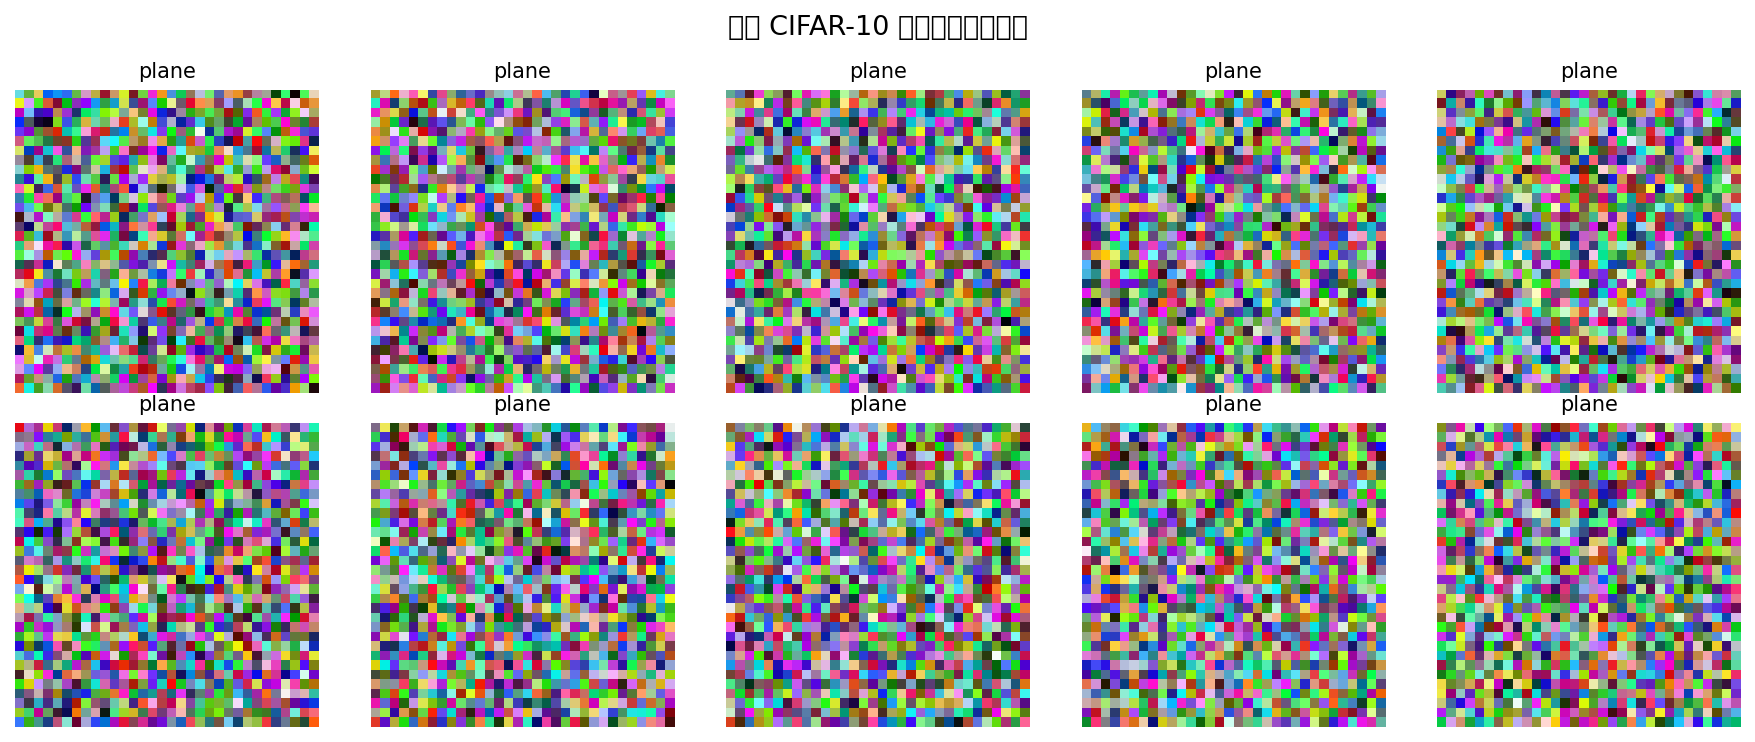

In [13]:
# 可视化几张图片
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = X_train[i].reshape(32, 32, 3)
    ax.imshow(img)
    ax.set_title(classes[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('迷你 CIFAR-10 样本（模拟数据）', fontsize=13)
plt.tight_layout()
plt.savefig('mini_cifar_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("图1：模拟数据看起来像噪声，但结构与真实数据一致")


## 4. 从零实现 Nearest Neighbor 分类器

现在实现最朴素的版本：对每张测试图，遍历所有训练图，找 L1 距离最小的那张。

**算法复杂度**：
- 训练：O(1)（只需存储）
- 预测：O(N·D)（N 张训练图，每张 D 维）

这意味着**预测极慢**——真实 CIFAR-10 的 50000 张训练图，预测一张测试图需要比较 50000 次。这就是 KNN 在实践中不实用的根本原因。


In [15]:
class NearestNeighbor:
    """最近邻分类器（L1 距离）"""

    def __init__(self):
        self.Xtr = None
        self.ytr = None

    def train(self, X, y):
        """训练 = 记住所有数据"""
        self.Xtr = X.astype(np.float64)
        self.ytr = y

    def predict_one(self, x):
        """预测单张图片"""
        distances = np.sum(np.abs(self.Xtr - x.astype(np.float64)), axis=1)
        best_idx = np.argmin(distances)
        return self.ytr[best_idx]

    def predict(self, X):
        """预测多张图片"""
        return np.array([self.predict_one(x) for x in X])

# 测试
nn = NearestNeighbor()
nn.train(X_train[:500], y_train[:500])

t0 = time.time()
predictions = nn.predict(X_test[:10])
t1 = time.time()
print(f"预测 10 张图片耗时: {t1-t0:.3f} 秒")
print(f"准确率: {np.mean(predictions == y_test[:10]):.2%}")


预测 10 张图片耗时: 0.082 秒
准确率: 30.00%


### 准确率为什么这么低？

随机数据的准确率应该接近 1/10 = 10%（随机猜测的水平）。实际结果可能会稍高或稍低。

这是因为随机生成的数据没有类别之间的结构差异——每类的像素分布几乎相同，KNN 无法区分。这说明了一个关键点：**分类器的效果取决于数据是否有可分的结构**。

接下来我们看看 L1 和 L2 两种距离度量的区别。


## 5. 距离度量：L1 vs L2

**L1 距离**（曼哈顿距离）：
$$d_1(x, y) = sum_j |x_j - y_j|$$

**L2 距离**（欧几里得距离）：
$$d_2(x, y) = sqrt{sum_j (x_j - y_j)^2}$$

两者的核心区别：

| 特性 | L1 距离 | L2 距离 |
|---|---|---|
| 对异常值 | 较稳健 | 敏感（平方放大） |
| 坐标系 | 依赖（旋转会变） | 不依赖 |
| 几何意义 | 网格距离 | 直线距离 |
| 计算量 | 较低 | 略高（需开方） |

如果特征的物理含义不同（比如一个是颜色、一个是位置），L1 更合适，因为各维度的尺度不同。如果特征是通用的像素值，L2 更常用。


### 手算对比

还是用之前的 A=[10,20,30,40], B=[15,18,25,50]：

- L1 = |10-15| + |20-18| + |30-25| + |40-50| = 5+2+5+10 = **22**
- L2 = sqrt(5^2 + 2^2 + 5^2 + 10^2) = sqrt(25+4+25+100) = sqrt(154) ≈ **12.41**

假设有一个异常维度：A'=[10,20,30,40], B'=[15,18,25,100]

- L1 = 5+2+5+60 = **72**（异常维度贡献 83%）
- L2 = sqrt(25+4+25+3600) = sqrt(3654) ≈ **60.45**（异常维度贡献 98%）

L2 的平方运算放大了大的差异，使它对异常值更敏感。


In [19]:
# 对比 L1 和 L2 距离在 KNN 中的表现

class NearestNeighborL2:
    """最近邻分类器（L2 距离）"""
    def __init__(self):
        self.Xtr = None
        self.ytr = None

    def train(self, X, y):
        self.Xtr = X.astype(np.float64)
        self.ytr = y

    def predict(self, X):
        predictions = []
        for x in X:
            distances = np.sqrt(np.sum((self.Xtr - x.astype(np.float64)) ** 2, axis=1))
            best_idx = np.argmin(distances)
            predictions.append(self.ytr[best_idx])
        return np.array(predictions)

# L1 和 L2 对比
nn_l1 = NearestNeighbor()
nn_l1.train(X_train[:500], y_train[:500])
pred_l1 = nn_l1.predict(X_test[:50])

nn_l2 = NearestNeighborL2()
nn_l2.train(X_train[:500], y_train[:500])
pred_l2 = nn_l2.predict(X_test[:50])

acc_l1 = np.mean(pred_l1 == y_test[:50])
acc_l2 = np.mean(pred_l2 == y_test[:50])
print(f"L1 距离准确率: {acc_l1:.2%}")
print(f"L2 距离准确率: {acc_l2:.2%}")
print(f"差距: {abs(acc_l1 - acc_l2):.2%}")


L1 距离准确率: 10.00%
L2 距离准确率: 8.00%
差距: 2.00%


## 6. K-最近邻（KNN）：从 1 到 K

最近邻只用 1 个邻居投票，容易受噪声影响。**KNN 的改进**：找最近的 K 个邻居，取多数投票。

**为什么 K > 1 更好？**

想象测试图片恰好落在两个类的边界附近。最近邻可能恰好是另一个类的噪声样本，导致误分类。但如果看最近 5 个邻居，多数会更可能属于正确的类。

K 是一个**超参数**——不是从数据中学到的，而是人为设定的。选择 K 的方法：**交叉验证**。


### 手算 KNN 投票

假设有 7 个训练样本，按距离排序后的标签为：

[猫, 猫, 狗, 猫, 狗, 狗, 鸟]

- K=1：最近邻是猫 → 预测**猫**
- K=3：前 3 个 = [猫, 猫, 狗] → 猫:2, 狗:1 → 预测**猫**
- K=5：前 5 个 = [猫, 猫, 狗, 猫, 狗] → 猫:3, 狗:2 → 预测**猫**
- K=7：全部 = [猫,猫,狗,猫,狗,狗,鸟] → 猫:3, 狗:3, 鸟:1 → **平局！**

K 的选择影响决策边界的平滑程度：K 越大，边界越平滑，模型越简单（偏差↑方差↓）。


In [22]:
class KNN:
    """K-最近邻分类器，支持 L1 和 L2 距离"""

    def __init__(self, k=1, distance='l1'):
        self.k = k
        self.distance = distance
        self.Xtr = None
        self.ytr = None

    def train(self, X, y):
        self.Xtr = X.astype(np.float64)
        self.ytr = y

    def predict(self, X):
        predictions = []
        for x in X:
            x = x.astype(np.float64)
            if self.distance == 'l1':
                dists = np.sum(np.abs(self.Xtr - x), axis=1)
            else:
                dists = np.sqrt(np.sum((self.Xtr - x) ** 2, axis=1))

            top_k_idx = np.argsort(dists)[:self.k]
            top_k_labels = self.ytr[top_k_idx]

            most_common = Counter(top_k_labels).most_common(1)[0][0]
            predictions.append(most_common)

        return np.array(predictions)

# 测试不同 K 值
print("=== KNN 不同 K 值的准确率 ===")
for k in [1, 3, 5, 7, 10]:
    knn = KNN(k=k, distance='l1')
    knn.train(X_train[:500], y_train[:500])
    pred = knn.predict(X_test[:50])
    acc = np.mean(pred == y_test[:50])
    print(f"K={k:2d}: 准确率 = {acc:.2%}")


=== KNN 不同 K 值的准确率 ===
K= 1: 准确率 = 10.00%
K= 3: 准确率 = 8.00%
K= 5: 准确率 = 6.00%
K= 7: 准确率 = 8.00%
K=10: 准确率 = 8.00%


## 7. 交叉验证：选择超参数 K

**问题**：我们不知道 K 取多少最好。能不能用测试集试不同 K？

**不行！** 测试集只能用一次——如果用测试集选 K，相当于偷看答案，会导致过拟合。

**解决方案**：交叉验证。把训练集分成若干份，轮流用其中一份做验证集：

1. 把训练集分成 5 份
2. 5 次实验，每次用 4 份训练、1 份验证
3. 取 5 次验证准确率的平均
4. 选平均准确率最高的 K

这就是 **5-fold 交叉验证**。


In [24]:
def cross_validate_knn(X, y, k_candidates, n_folds=5, distance='l1'):
    """K-fold 交叉验证选择最佳 K"""
    n = len(X)
    fold_size = n // n_folds
    indices = np.random.RandomState(42).permutation(n)

    results = {}
    for k in k_candidates:
        fold_accuracies = []
        for fold in range(n_folds):
            val_idx = indices[fold * fold_size : (fold + 1) * fold_size]
            train_idx = np.setdiff1d(indices, val_idx)

            knn = KNN(k=k, distance=distance)
            knn.train(X[train_idx], y[train_idx])
            pred = knn.predict(X[val_idx])
            fold_accuracies.append(np.mean(pred == y[val_idx]))

        results[k] = {'mean': np.mean(fold_accuracies), 'std': np.std(fold_accuracies), 'folds': fold_accuracies}
    return results

k_candidates = [1, 3, 5, 7, 10, 15, 20]
cv_results = cross_validate_knn(X_train[:500], y_train[:500], k_candidates, n_folds=5)

print("=== 交叉验证结果 ===")
for k in k_candidates:
    r = cv_results[k]
    print(f"K={k:2d}: {r['mean']:.2%} ± {r['std']:.2%}")


=== 交叉验证结果 ===
K= 1: 19.00% ± 2.28%
K= 3: 18.20% ± 2.93%
K= 5: 17.60% ± 3.72%
K= 7: 19.40% ± 5.08%
K=10: 20.80% ± 1.17%
K=15: 17.20% ± 1.17%
K=20: 17.20% ± 2.40%


图2：交叉验证帮助选择最佳 K 值


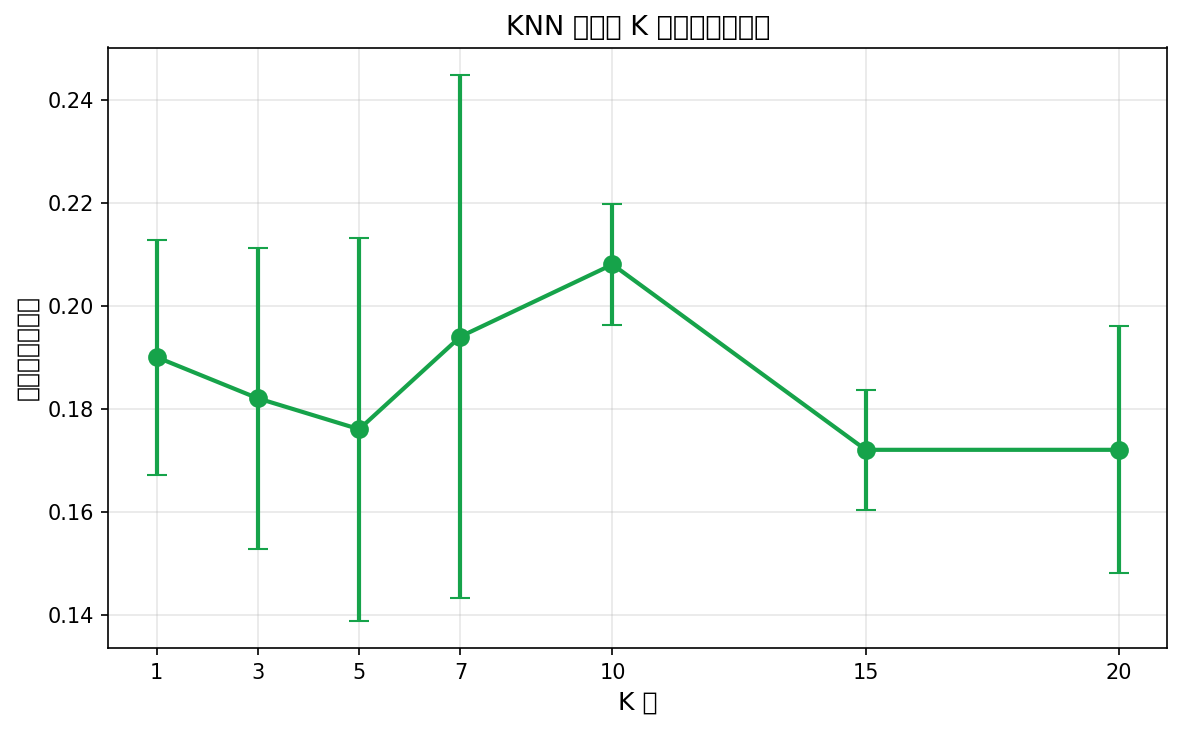

In [25]:
# 可视化交叉验证结果
fig, ax = plt.subplots(figsize=(8, 5))

k_values = list(cv_results.keys())
means = [cv_results[k]['mean'] for k in k_values]
stds = [cv_results[k]['std'] for k in k_values]

ax.errorbar(k_values, means, yerr=stds, marker='o', capsize=5,
           color='#16a34a', linewidth=2, markersize=8)
ax.set_xlabel('K 值', fontsize=12)
ax.set_ylabel('交叉验证准确率', fontsize=12)
ax.set_title('KNN 超参数 K 的交叉验证结果', fontsize=13)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knn_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("图2：交叉验证帮助选择最佳 K 值")


## 8. KNN 为什么在图像分类中行不通

KNN 在低维数据上效果不错，但在图像分类中几乎不用。原因有三个：

### 8.1 计算量

- 训练 50000 张 CIFAR-10 → 预测 1 张测试图需要比较 50000 次
- 每次 3072 维 → 总运算量 = 50000 × 3072 ≈ **1.5 亿次**
- 即使向量化，单张预测也要数百毫秒

### 8.2 维度灾难

KNN 依赖距离近的样本标签相似这个假设。但在高维空间中，这个假设**失效**了。

维度越高，所有点之间的距离趋于相同——最近邻和最远邻的距离差异越来越小。在 3072 维空间里，最近的图片可能和最远的图片差不多远。


### 8.3 语义不匹配

L1 和 L2 距离衡量的是**像素级的差异**，但人眼判断相似性用的是**语义特征**——形状、纹理、物体部件。

举例：同一只猫，左移 2 像素 → L1 距离可能暴增（每个像素都变了），但语义完全相同。这种平移不变性是 KNN 无法捕捉的。

**实验验证**：把一张图片整体右移 5 像素，计算它与原图的 L1 距离——会非常大，即使内容完全一样。


In [28]:
# 演示平移不变性问题
img = np.random.randint(0, 256, (32, 32, 3), dtype=np.uint8)

# 原图 vs 平移 1 像素的图
img_shifted = np.zeros_like(img)
img_shifted[:, 1:] = img[:, :-1]

l1_original = 0
l1_shifted_1px = np.sum(np.abs(img.astype(float) - img_shifted.astype(float)))

# 平移 5 像素
img_shifted_5 = np.zeros_like(img)
img_shifted_5[:, 5:] = img[:, :-5]
l1_shifted_5px = np.sum(np.abs(img.astype(float) - img_shifted_5.astype(float)))

# 与随机图片的距离
img_random = np.random.randint(0, 256, (32, 32, 3), dtype=np.uint8)
l1_random = np.sum(np.abs(img.astype(float) - img_random.astype(float)))

print("=== 平移不变性实验 ===")
print(f"与自身的 L1 距离:           {l1_original:>10.0f}")
print(f"与平移 1 像素的 L1 距离:   {l1_shifted_1px:>10.0f}")
print(f"与平移 5 像素的 L1 距离:   {l1_shifted_5px:>10.0f}")
print(f"与随机图片的 L1 距离:       {l1_random:>10.0f}")
print()
print("结论：平移 1 像素 → L1 距离剧增，但语义完全不变")
print("KNN 无法理解这种语义不变性")


=== 平移不变性实验 ===
与自身的 L1 距离:                    0
与平移 1 像素的 L1 距离:       273764
与平移 5 像素的 L1 距离:       276957
与随机图片的 L1 距离:           257800

结论：平移 1 像素 → L1 距离剧增，但语义完全不变
KNN 无法理解这种语义不变性


## 9. 2D 决策边界可视化

为了直观理解 KNN 的行为，我们在 2 维空间画出决策边界。用 2D 数据可以清晰看到 K 对边界的影响。

- K=1：边界曲折，对噪声敏感（过拟合）
- K=5：边界更平滑
- K=15：边界非常平滑，可能过于简单（欠拟合）


In [30]:
# 生成 2D 模拟数据
from sklearn.datasets import make_moons

X_2d, y_2d = make_moons(n_samples=200, noise=0.15, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
k_values = [1, 5, 15]

for ax, k in zip(axes, k_values):
    knn_2d = KNN(k=k, distance='l2')
    knn_2d.train(X_2d, y_2d)

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80),
                         np.linspace(y_min, y_max, 80))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = knn_2d.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='RdBu', edgecolors='k', s=30)
    ax.set_title(f'K={k}', fontsize=13)

plt.suptitle('KNN 决策边界：K 值对模型复杂度的影响', fontsize=14)
plt.tight_layout()
plt.savefig('knn_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("图3：K 越大，决策边界越平滑，模型越简单")


ModuleNotFoundError: No module named 'sklearn'

## 10. 时间复杂度分析

KNN 的计算成本是它在实践中不实用的最直接原因：

| 阶段 | 训练 | 预测（单张） |
|---|---|---|
| KNN | O(1) | O(N·D) |
| 线性分类器 | O(N·D) | O(D) |
| CNN | O(N·D·E) | O(D·E) |

- N = 训练样本数
- D = 特征维度
- E = 训练轮数

关键区别：KNN 把计算量**推迟到预测时**，而其他方法在**训练时**花时间学习参数，预测时只需一次前向传播。在实际部署中，预测速度远比训练速度重要。


训练集大小   100: 预测 5 张耗时 0.0060 秒 (1.2 ms/张)
训练集大小   200: 预测 5 张耗时 0.0207 秒 (4.1 ms/张)
训练集大小   500: 预测 5 张耗时 0.0415 秒 (8.3 ms/张)
训练集大小  1000: 预测 5 张耗时 0.0824 秒 (16.5 ms/张)
训练集大小  2000: 预测 5 张耗时 0.0798 秒 (16.0 ms/张)
图4：KNN 预测时间与训练集大小成线性关系


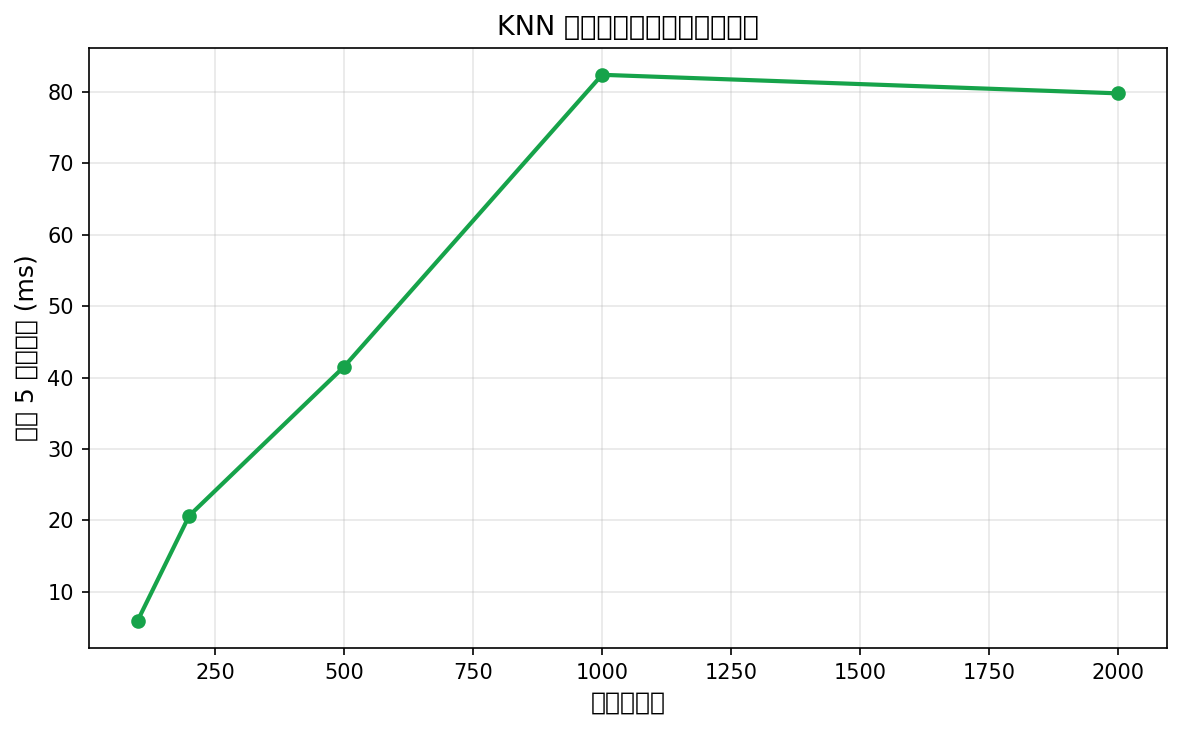

In [32]:
# 基准测试：KNN 预测时间 vs 训练集大小
sizes = [100, 200, 500, 1000, 2000]
times = []

for n in sizes:
    knn = KNN(k=3, distance='l1')
    knn.train(X_train[:n], y_train[:n])

    t0 = time.time()
    knn.predict(X_test[:5])
    t1 = time.time()
    times.append(t1 - t0)
    print(f"训练集大小 {n:5d}: 预测 5 张耗时 {t1-t0:.4f} 秒 ({(t1-t0)/5*1000:.1f} ms/张)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, [t * 1000 for t in times], 'o-', color='#16a34a', linewidth=2)
ax.set_xlabel('训练集大小', fontsize=12)
ax.set_ylabel('预测 5 张的耗时 (ms)', fontsize=12)
ax.set_title('KNN 预测时间随训练集线性增长', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knn_time_complexity.png', dpi=150, bbox_inches='tight')
plt.show()
print("图4：KNN 预测时间与训练集大小成线性关系")


## 作业

以下练习帮助你深入理解 KNN。建议先自己尝试，再对照参考答案。

> 注意：可以让 AI 解释思路，但不建议直接让 AI 做完题目。


### 作业 1：实现加权 KNN

普通 KNN 中，K 个邻居的投票权重相同。但在直觉上，**距离更近的邻居应该有更大的权重**。

**任务**：实现加权 KNN，权重与距离成反比 wi = 1/di。

**要求**：
- 补全 WeightedKNN 类的 predict 方法
- 对比普通 KNN 和加权 KNN 的准确率
- 思考：什么时候加权更好？什么时候更差？


In [35]:
class WeightedKNN:
    """加权 KNN 分类器"""
    def __init__(self, k=3, distance='l1'):
        self.k = k
        self.distance = distance

    def train(self, X, y):
        self.Xtr = X.astype(np.float64)
        self.ytr = y

    def predict(self, X):
        predictions = []
        for x in X:
            x = x.astype(np.float64)
            if self.distance == 'l1':
                dists = np.sum(np.abs(self.Xtr - x), axis=1)
            else:
                dists = np.sqrt(np.sum((self.Xtr - x) ** 2, axis=1))

            top_k_idx = np.argsort(dists)[:self.k]
            top_k_dists = dists[top_k_idx]
            top_k_labels = self.ytr[top_k_idx]

            # 加权投票：权重 = 1 / (距离 + 1e-8)
            weights = 1.0 / (top_k_dists + 1e-8)
            label_scores = {}
            for label, w in zip(top_k_labels, weights):
                label_scores[label] = label_scores.get(label, 0) + w

            best_label = max(label_scores, key=label_scores.get)
            predictions.append(best_label)

        return np.array(predictions)

# 对比测试
knn_normal = KNN(k=5, distance='l1')
knn_normal.train(X_train[:500], y_train[:500])
pred_normal = knn_normal.predict(X_test[:50])

knn_weighted = WeightedKNN(k=5, distance='l1')
knn_weighted.train(X_train[:500], y_train[:500])
pred_weighted = knn_weighted.predict(X_test[:50])

print(f"普通 KNN (K=5):   {np.mean(pred_normal == y_test[:50]):.2%}")
print(f"加权 KNN (K=5):   {np.mean(pred_weighted == y_test[:50]):.2%}")


普通 KNN (K=5):   6.00%
加权 KNN (K=5):   6.00%


### 作业 2：L1 vs L2 决策边界

**任务**：在 2D 月亮数据集上，分别用 L1 和 L2 距离画 KNN 的决策边界。

**思考题**：
1. L1 和 L2 的决策边界形状有什么区别？
2. 为什么 L1 的边界倾向于轴向（平行于坐标轴），而 L2 倾向于旋转？
3. 在什么情况下你会选择 L1 而非 L2？


In [37]:
# 作业 2：L1 vs L2 决策边界
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, dist_metric in zip(axes, ['l1', 'l2']):
    knn_2d = KNN(k=5, distance=dist_metric)
    knn_2d.train(X_2d, y_2d)

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 80),
                         np.linspace(y_min, y_max, 80))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = knn_2d.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='RdBu', edgecolors='k', s=30)
    ax.set_title(f'K=5, {dist_metric.upper()} 距离', fontsize=12)

plt.suptitle('L1 vs L2 决策边界对比', fontsize=13)
plt.tight_layout()
plt.savefig('knn_l1_vs_l2.png', dpi=150, bbox_inches='tight')
plt.show()
print("图5：L1 决策边界倾向轴向，L2 倾向旋转")


NameError: name 'X_2d' is not defined

### 作业 3：维度灾难实验

**任务**：验证维度灾难——当维度增加时，最近邻和最远邻的距离之比趋近于 1。

**步骤**：
1. 在维度 D = 1, 10, 100, 1000 下，随机生成 200 个点
2. 对每个点，计算到其他所有点的距离
3. 计算 (最近距离 / 最远距离) 的平均值
4. 画出比值随维度的变化

**思考**：当比值趋近 1 时，最近邻还有意义吗？


D=   1: 最近/最远 距离比 = 0.0036
D=   2: 最近/最远 距离比 = 0.0343
D=   5: 最近/最远 距离比 = 0.1806
D=  10: 最近/最远 距离比 = 0.3411
D=  50: 最近/最远 距离比 = 0.6466
D= 100: 最近/最远 距离比 = 0.7373
D= 500: 最近/最远 距离比 = 0.8740
D=1000: 最近/最远 距离比 = 0.9085
D=3072: 最近/最远 距离比 = 0.9478
图6：维度越高，最近邻与最远邻的距离越接近


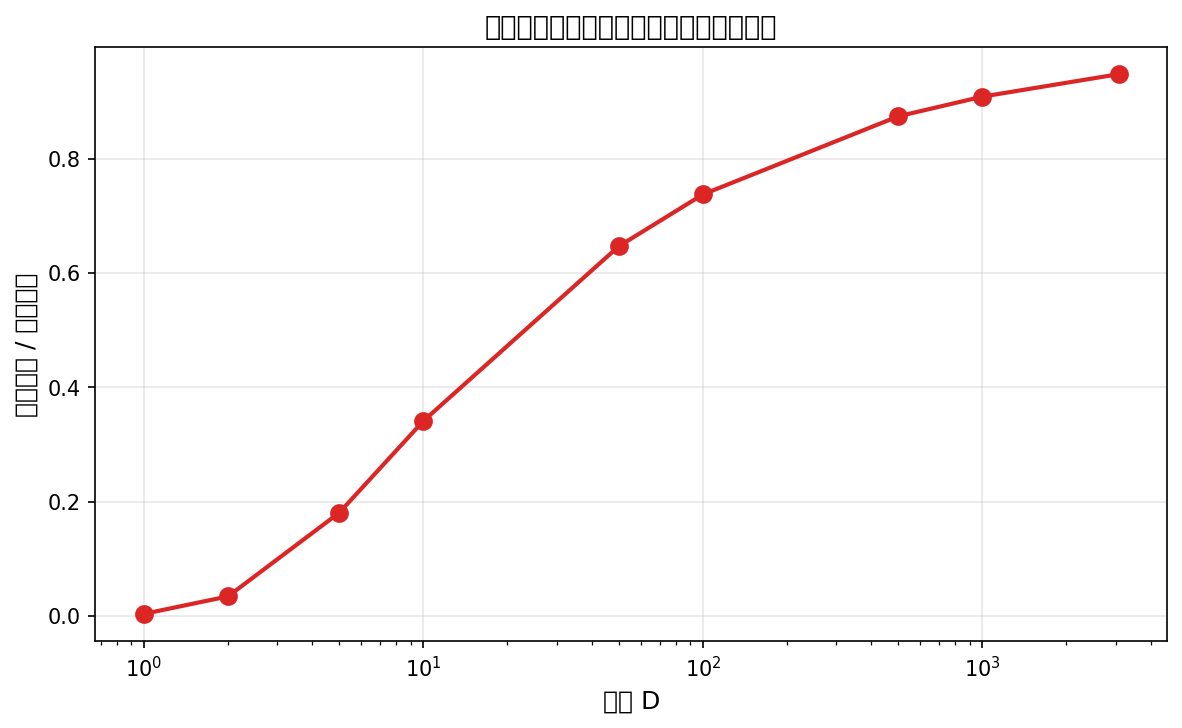

In [39]:
# 维度灾难实验
dims = [1, 2, 5, 10, 50, 100, 500, 1000, 3072]
ratios = []

for D in dims:
    np.random.seed(42)
    points = np.random.rand(200, D)

    nearest_dists = []
    farthest_dists = []
    for i in range(200):
        dists = np.sqrt(np.sum((points - points[i]) ** 2, axis=1))
        dists = dists[dists > 0]
        nearest_dists.append(np.min(dists))
        farthest_dists.append(np.max(dists))

    ratio = np.mean(np.array(nearest_dists) / np.array(farthest_dists))
    ratios.append(ratio)
    print(f"D={D:4d}: 最近/最远 距离比 = {ratio:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dims, ratios, 'o-', color='#dc2626', linewidth=2, markersize=8)
ax.set_xlabel('维度 D', fontsize=12)
ax.set_ylabel('最近距离 / 最远距离', fontsize=12)
ax.set_title('维度灾难：高维空间中所有距离趋于相同', fontsize=13)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curse_of_dimensionality.png', dpi=150, bbox_inches='tight')
plt.show()
print("图6：维度越高，最近邻与最远邻的距离越接近")


## 小结

本讲从计算机视觉的基本问题出发，用 KNN 作为切入点理解了几个关键概念：

| 概念 | 要点 |
|---|---|
| 语义鸿沟 | 像素值与语义概念之间的巨大差距 |
| L1/L2 距离 | 像素级距离度量，各有优劣 |
| KNN | 朴素分类器，K 控制模型复杂度 |
| 交叉验证 | 超参数选择的标准方法 |
| 维度灾难 | 高维空间中距离失效 |
| 平移不变性 | 像素级距离无法捕捉语义不变性 |

**KNN 的三大缺陷**：
1. 预测太慢（O(ND)）
2. 维度灾难（高维距离失效）
3. 语义不匹配（像素差异 ≠ 语义差异）

这些缺陷推动我们从记忆+比较走向参数化学习——下一讲的线性分类器就是第一步。


## 参考资料

- [[Krizhevsky, 2009]](https://www.cs.toronto.edu/~kriz/learning.html) Krizhevsky, A. *Learning Multiple Layers of Features from Tiny Images*. CIFAR-10 数据集.
- [[Cover and Hart, 1967]](https://ieeexplore.ieee.org/document/4040456) Cover, T. and Hart, P. *Nearest Neighbor Pattern Classification*. IEEE Transactions on Information Theory.
- [[Beygelzimer et al., 2006]](https://papers.nips.cc/paper/2666-cover-trees-for-nearest-neighbor) Beygelzimer et al. *Cover Trees for Nearest Neighbor*. 近邻搜索加速算法.
- [CS231n Assignment 1](https://cs231n.github.io/assignments2021/assignment1/) KNN 完整作业.
- [Stanford CS231n](https://cs231n.stanford.edu/) 课程官网.


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): CS231n 完整作业解答（KNN、SVM、Softmax、两层网络）
  - 仓库地址: https://github.com/jariasf/CS231n

- **[rishabh-16/cs231n-2019-assignments](https://github.com/rishabh-16/cs231n-2019-assignments)** (212 stars): 2019版 CS231n 作业 PyTorch+TensorFlow 解答
  - 仓库地址: https://github.com/rishabh-16/cs231n-2019-assignments

- **[amanchadha/stanford-cs231n-assignments-2020](https://github.com/amanchadha/stanford-cs231n-assignments-2020)** (175 stars): 2020春季 CS231n 完整作业解答
  - 仓库地址: https://github.com/amanchadha/stanford-cs231n-assignments-2020


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

